In [1]:
import pandas as pd

df = pd.read_csv(
    "Global_Mental_Health_Dataset_2025.csv"
)

df.head()

,Patient_ID,Age,Gender,Country,Depression_Score,Anxiety_Score,Stress_Level,Sleep_Hours,Physical_Activity,Chronic_Illness,Mental_Health_History,Treatment,Days_of_Treatment,Outcome,Work_Status
0,MH0001,56,Male,Germany,4,10,High,8.2,Moderate,No,No,Therapy,171,Excellent,Unemployed
1,MH0002,69,Male,South Africa,22,4,Severe,6.2,Low,No,Yes,NaN,69,Fair,Employed
2,MH0003,46,Male,South Africa,4,2,Low,10.4,NaN,Yes,Yes,Medication,70,Good,Employed
3,MH0004,32,Female,Australia,19,16,Low,10.0,Moderate,No,Yes,Both,254,Excellent,Employed
4,MH0005,60,Female,United States,14,1,Severe,7.9,Low,Yes,No,Therapy,130,Fair,Employed


In [2]:
selected_df = df[[
    "Age",
    "Gender",
    "Depression_Score",
    "Anxiety_Score"
]]

selected_df.head()

,Age,Gender,Depression_Score,Anxiety_Score
0,56,Male,4,10
1,69,Male,22,4
2,46,Male,4,2
3,32,Female,19,16
4,60,Female,14,1


In [3]:
# Selecting important columns for ANA-2

selected_df = df[[
    "Age",
    "Gender",
    "Depression_Score",
    "Anxiety_Score",
    "Stress_Level",
    "Sleep_Hours",
    "Mental_Health_History",
    "Treatment",
    "Outcome"
]]

# Display first rows
selected_df.head()

,Age,Gender,Depression_Score,Anxiety_Score,Stress_Level,Sleep_Hours,Mental_Health_History,Treatment,Outcome
0,56,Male,4,10,High,8.2,No,Therapy,Excellent
1,69,Male,22,4,Severe,6.2,Yes,NaN,Fair
2,46,Male,4,2,Low,10.4,Yes,Medication,Good
3,32,Female,19,16,Low,10.0,Yes,Both,Excellent
4,60,Female,14,1,Severe,7.9,No,Therapy,Fair


In [4]:
# Dataset information

selected_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    2500 non-null   int64  
 1   Gender                 2500 non-null   object 
 2   Depression_Score       2500 non-null   int64  
 3   Anxiety_Score          2500 non-null   int64  
 4   Stress_Level           2500 non-null   object 
 5   Sleep_Hours            2500 non-null   float64
 6   Mental_Health_History  2500 non-null   object 
 7   Treatment              1892 non-null   object 
 8   Outcome                2500 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 175.9+ KB


In [5]:
# Missing values check

selected_df.isnull().sum()

,0
Age,0
Gender,0
Depression_Score,0
Anxiety_Score,0
Stress_Level,0
Sleep_Hours,0
Mental_Health_History,0
Treatment,608
Outcome,0


In [6]:
# Statistical summary

selected_df.describe()

,Age,Depression_Score,Anxiety_Score,Sleep_Hours
count,2500.000000,2500.000000,2500.000000,2500.000000
mean,49.580800,13.518400,10.502800,7.461600
std,18.213933,8.082561,6.329267,2.591345
min,18.000000,0.000000,0.000000,3.000000
25%,34.000000,6.000000,5.000000,5.300000
50%,50.000000,14.000000,11.000000,7.500000
75%,66.000000,21.000000,16.000000,9.700000
max,80.000000,27.000000,21.000000,12.000000


In [7]:
# Gender-wise average scores

gender_analysis = selected_df.groupby("Gender")[[
    "Depression_Score",
    "Anxiety_Score"
]].mean()

gender_analysis

,Depression_Score,Anxiety_Score
Gender,,
Female,13.376685,10.451229
Male,13.662631,10.555287


gender wise comparison bar chart

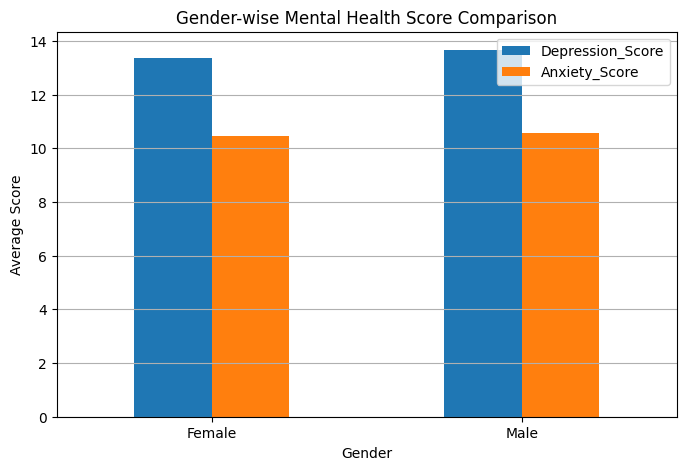

In [8]:
import matplotlib.pyplot as plt

gender_analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Gender-wise Mental Health Score Comparison"
)

plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.grid(axis='y')

plt.show()

/tmp/ipykernel_11087/359251609.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


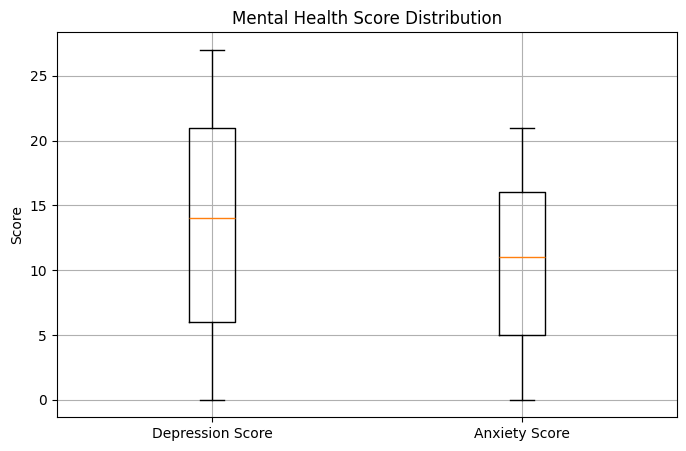

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot([
    selected_df["Depression_Score"],
    selected_df["Anxiety_Score"]
],
labels=[
    "Depression Score",
    "Anxiety Score"
])

plt.title(
    "Mental Health Score Distribution"
)

plt.ylabel("Score")

plt.grid()

plt.show()

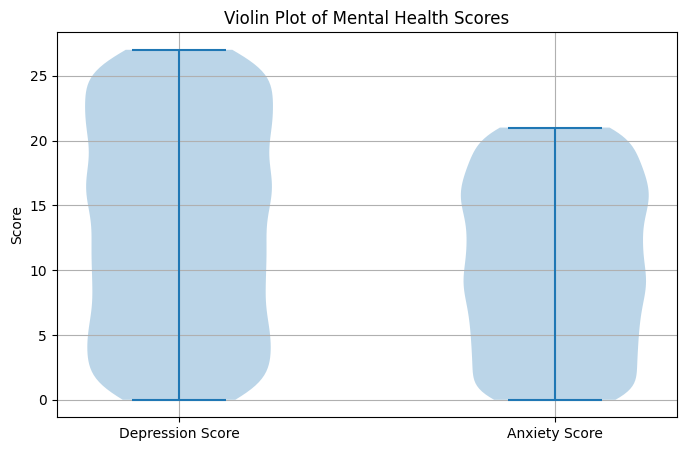

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.violinplot([
    selected_df["Depression_Score"],
    selected_df["Anxiety_Score"]
])

plt.xticks(
    [1,2],
    ["Depression Score", "Anxiety Score"]
)

plt.ylabel("Score")

plt.title(
    "Violin Plot of Mental Health Scores"
)

plt.grid()

plt.show()

In [11]:
# Creating age groups

selected_df["Age_Group"] = pd.cut(
    selected_df["Age"],
    bins=[18, 30, 45, 60, 80],
    labels=[
        "18-30",
        "31-45",
        "46-60",
        "61-80"
    ]
)

selected_df.head()

/tmp/ipykernel_11087/3837575407.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df["Age_Group"] = pd.cut(


,Age,Gender,Depression_Score,Anxiety_Score,Stress_Level,Sleep_Hours,Mental_Health_History,Treatment,Outcome,Age_Group
0,56,Male,4,10,High,8.2,No,Therapy,Excellent,46-60
1,69,Male,22,4,Severe,6.2,Yes,NaN,Fair,61-80
2,46,Male,4,2,Low,10.4,Yes,Medication,Good,46-60
3,32,Female,19,16,Low,10.0,Yes,Both,Excellent,31-45
4,60,Female,14,1,Severe,7.9,No,Therapy,Fair,46-60


In [12]:
# Age-wise average scores

age_analysis = selected_df.groupby("Age_Group")[[
    "Depression_Score",
    "Anxiety_Score"
]].mean()

age_analysis

/tmp/ipykernel_11087/2497099274.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_analysis = selected_df.groupby("Age_Group")[[


,Depression_Score,Anxiety_Score
Age_Group,,
18-30,12.988938,10.400442
31-45,13.409247,10.544521
46-60,14.301003,10.500000
61-80,13.357143,10.519370


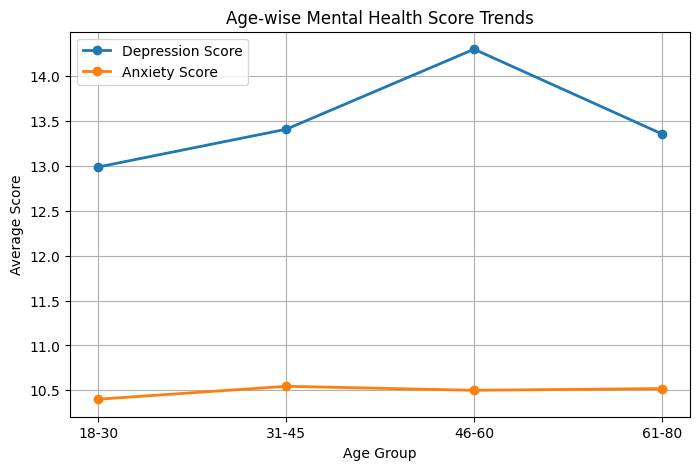

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    age_analysis.index,
    age_analysis["Depression_Score"],
    marker='o',
    linewidth=2,
    label="Depression Score"
)

plt.plot(
    age_analysis.index,
    age_analysis["Anxiety_Score"],
    marker='o',
    linewidth=2,
    label="Anxiety Score"
)

plt.title(
    "Age-wise Mental Health Score Trends"
)

plt.xlabel("Age Group")

plt.ylabel("Average Score")

plt.legend()

plt.grid()

plt.show()

In [15]:
selected_df

,Age,Gender,Depression_Score,Anxiety_Score,Stress_Level,Sleep_Hours,Mental_Health_History,Treatment,Outcome,Age_Group
0,56,Male,4,10,High,8.2,No,Therapy,Excellent,46-60
1,69,Male,22,4,Severe,6.2,Yes,NaN,Fair,61-80
2,46,Male,4,2,Low,10.4,Yes,Medication,Good,46-60
3,32,Female,19,16,Low,10.0,Yes,Both,Excellent,31-45
4,60,Female,14,1,Severe,7.9,No,Therapy,Fair,46-60
...,...,...,...,...,...,...,...,...,...,...
2495,64,Female,21,20,Severe,6.9,Yes,Therapy,Poor,61-80
2496,48,Male,22,0,High,9.2,No,Medication,Fair,46-60
2497,55,Female,4,18,Low,7.7,No,NaN,Fair,46-60
2498,49,Male,8,0,High,11.8,No,NaN,Fair,46-60


In [16]:
# Save cleaned dataset

selected_df.to_csv(
    "cleaned_mental_health_dataset.csv",
    index=False
)